# Visualisasi Analisis Evaluasi Top-1 sampai Top-20

Notebook ini dibuat sebagai artefak audit untuk Bab 6. Data yang dipakai berasal dari hasil evaluasi final dan artefak analisis di `results/final/analysis/`.

Scope:
- Top-k: 1 sampai 20
- Metode: Element-Based, Max-Min Semantic, Recursive
- Metrik: Precision@k, Recall@k, MRR, F1@k, BLEU, ROUGE-L
- Output grafik: `results/final/analysis/figures/`

Catatan metodologis: notebook ini tidak menjalankan retrieval, generation, embedding, atau model. Notebook hanya membaca hasil evaluasi final/agregat yang sudah tersedia.

In [10]:
# Setup dan load data analisis Top-1 sampai Top-20
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

TOPK_MIN = 1
TOPK_MAX = 20

ANALYSIS_DIR = Path("../results/final/analysis")
FIG_DIR = Path("../results/final/analysis/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

METRICS_BY_K_PATH = ANALYSIS_DIR / "top1_20_metrics_by_k.csv"
SUMMARY_PATH = ANALYSIS_DIR / "top1_20_metric_summary_by_method.csv"
WINNERS_PATH = ANALYSIS_DIR / "top1_20_metric_winners.csv"

metrics_by_k = pd.read_csv(METRICS_BY_K_PATH)
summary_by_method = pd.read_csv(SUMMARY_PATH)
metric_winners = pd.read_csv(WINNERS_PATH)

required_columns = {
    "top_k",
    "method",
    "precision_at_k",
    "recall_at_k",
    "mrr",
    "f1_at_k",
    "bleu",
    "rouge_l",
}
missing_columns = required_columns - set(metrics_by_k.columns)
if missing_columns:
    raise ValueError(f"Kolom wajib tidak ditemukan pada {METRICS_BY_K_PATH}: {sorted(missing_columns)}")

expected_topks = set(range(TOPK_MIN, TOPK_MAX + 1))
actual_topks = set(metrics_by_k["top_k"].astype(int).unique())
if actual_topks != expected_topks:
    raise ValueError(f"Top-k tidak lengkap. Expected={sorted(expected_topks)}, actual={sorted(actual_topks)}")

METHOD_ORDER = ["Element-Based", "MaxMin Semantic", "Recursive"]
METHOD_LABELS = {
    "Element-Based": "Element-Based",
    "MaxMin Semantic": "Max-Min Semantic",
    "Recursive": "Recursive",
}
METHOD_COLORS = {
    "Element-Based": "#1f77b4",
    "MaxMin Semantic": "#ff7f0e",
    "Recursive": "#2ca02c",
}
METHOD_MARKERS = {
    "Element-Based": "o",
    "MaxMin Semantic": "s",
    "Recursive": "^",
}
METHOD_LINESTYLES = {
    "Element-Based": "-",
    "MaxMin Semantic": "-",
    "Recursive": "-",
}

LABEL_TOPKS = list(range(TOPK_MIN, TOPK_MAX + 1))
metrics_by_k.head()

,top_k,method,method_key,qa_rows,precision_at_k,recall_at_k,mrr,f1_at_k,bleu,rouge_l,...,n_recall,n_mrr,n_bleu,n_rouge_l,missing_precision,missing_recall,missing_mrr,missing_bleu,missing_rouge_l,source_file
0,1,Element-Based,element_based,30,0.2857,0.1994,0.2857,0.2349,0.1542,0.6270,...,28,28,30,30,2,2,2,0,0,results/final/generation/eval_20260531_181551_...
1,1,MaxMin Semantic,maxmin_semantic,30,0.2069,0.1264,0.2069,0.1570,0.1252,0.6013,...,29,29,30,30,1,1,1,0,0,results/final/generation/eval_20260531_181551_...
2,1,Recursive,recursive,30,0.3448,0.1488,0.3448,0.2079,0.1426,0.6406,...,29,29,30,30,1,1,1,0,0,results/final/generation/eval_20260531_181551_...
3,2,Element-Based,element_based,30,0.1786,0.2440,0.3036,0.2062,0.1299,0.6918,...,28,28,30,30,2,2,2,0,0,results/final/generation/eval_20260531_182241_...
4,2,MaxMin Semantic,maxmin_semantic,30,0.2069,0.2672,0.2931,0.2332,0.1224,0.6237,...,29,29,30,30,1,1,1,0,0,results/final/generation/eval_20260531_182241_...


In [11]:
# Helper visualisasi metrik
METRIC_LABEL_PATTERNS = {
    "precision_at_k": "precision",
    "recall_at_k": "recall",
    "mrr": "mrr",
    "f1_at_k": "f1",
    "bleu": "bleu",
    "rouge_l": "rouge",
}

BASE_LABEL_OFFSETS = {
    "Element-Based": (0, 18),
    "MaxMin Semantic": (0, -18),
    "Recursive": (0, 18),
}

MANUAL_LABEL_OFFSETS = {
    "precision_at_k": {
        ("Element-Based", 2): (0, -14),
        ("Element-Based", 3): (0, -14),
        ("MaxMin Semantic", 4): (0, -14),
        ("MaxMin Semantic", 5): (0, 8),
        ("Recursive", 4): (0, 10),
        ("Element-Based", 7): (0, 8),
        ("Element-Based", 8): (0, 8),
        ("Element-Based", 9): (0, -14),
        ("Element-Based", 10): (0, 0),
        ("MaxMin Semantic", 10): (0, -10),
    },
    "recall_at_k": {
        ("MaxMin Semantic", 1): (0, -16),
        ("Element-Based", 2): (0, -16),
        ("MaxMin Semantic", 2): (0, 20),
        ("Recursive", 2): (0, -18),
        ("Element-Based", 3): (0, -10),
        ("Element-Based", 4): (0, -16),
        ("MaxMin Semantic", 4): (0, 18),
        ("Element-Based", 5): (0, -10),
        ("Element-Based", 6): (0, -10),
        ("Element-Based", 7): (0, -10),
        ("Element-Based", 8): (0, 16),
        ("Element-Based", 9): (0, -16),
        ("Element-Based", 10): (0, -16),
        ("MaxMin Semantic", 8): (0, -18),
        ("Recursive", 3): (0, -16),
        ("Recursive", 4): (0, -16),
        ("Recursive", 5): (0, -16),
        ("Recursive", 6): (0, -16),
        ("Recursive", 7): (0, -16),
        ("Recursive", 8): (0, -16),
        ("Recursive", 9): (0, -16),
        ("Recursive", 10): (0, -16),
    },
    "mrr": {},
    "f1_at_k": {
        ("Element-Based", 2): (0, -12),
        ("MaxMin Semantic", 2): (0, 16),
        ("Recursive", 2): (0, 18),
        ("Element-Based", 3): (0, -16),
        ("MaxMin Semantic", 3): (-8, 16),
        ("Recursive", 3): (8, 22),
        ("Element-Based", 4): (0, -16),
        ("MaxMin Semantic", 4): (-8, -18),
        ("Recursive", 4): (8, 18),
        ("Element-Based", 5): (0, -10),
        ("MaxMin Semantic", 5): (0, 8),
        ("Recursive", 9): (0, 8),
        ("Element-Based", 9): (0, -10),
        ("Element-Based", 10): (0, -10),
    },
    "bleu": {
        ("Element-Based", 1): (0, 14),
        ("MaxMin Semantic", 1): (0, 14),
        ("Recursive", 1): (0, 14),
        ("Element-Based", 2): (0, 14),
        ("MaxMin Semantic", 2): (0, 14),
        ("Recursive", 2): (0, 14),
        ("Element-Based", 3): (0, 12),
        ("MaxMin Semantic", 3): (0, 14),
        ("Recursive", 3): (0, 14),
        ("Element-Based", 4): (0, -14),
        ("MaxMin Semantic", 4): (0, 14),
        ("Recursive", 4): (0, 14),
        ("Element-Based", 5): (0, 14),
        ("MaxMin Semantic", 5): (0, -16),
        ("Recursive", 5): (0, 14),
        ("Element-Based", 6): (0, -14),
        ("MaxMin Semantic", 6): (0, 14),
        ("Recursive", 6): (0, 14),
        ("Element-Based", 7): (0, 14),
        ("MaxMin Semantic", 7): (0, -14),
        ("Recursive", 7): (0, 14),
        ("Element-Based", 8): (0, -14),
        ("MaxMin Semantic", 8): (0, 14),
        ("Recursive", 8): (0, 14),
        ("Element-Based", 9): (0, 14),
        ("MaxMin Semantic", 9): (0, -14),
        ("Recursive", 9): (0, 14),
        ("Element-Based", 10): (0, -14),
        ("MaxMin Semantic", 10): (0, 14),
        ("Recursive", 10): (0, 14),
        ("Element-Based", 19): (-8, -16),
        ("MaxMin Semantic", 19): (8, 16),
        ("Element-Based", 20): (-8, -16),
        ("MaxMin Semantic", 20): (8, 16),
    },
    "rouge_l": {
        ("Element-Based", 1): (0, 14),
        ("MaxMin Semantic", 1): (0, -16),
        ("Recursive", 1): (0, 14),
        ("Element-Based", 2): (0, 14),
        ("MaxMin Semantic", 2): (0, 14),
        ("Recursive", 2): (0, 14),
        ("Element-Based", 3): (0, 14),
        ("MaxMin Semantic", 3): (0, -16),
        ("Recursive", 3): (0, 14),
        ("Element-Based", 4): (-8, -18),
        ("MaxMin Semantic", 4): (8, 18),
        ("Recursive", 4): (0, 14),
        ("Element-Based", 5): (0, 14),
        ("MaxMin Semantic", 5): (0, 14),
        ("Recursive", 5): (0, 14),
        ("Element-Based", 6): (0, 14),
        ("MaxMin Semantic", 6): (0, -16),
        ("Recursive", 6): (0, 14),
        ("Element-Based", 7): (0, 14),
        ("MaxMin Semantic", 7): (0, -16),
        ("Recursive", 7): (0, 14),
        ("Element-Based", 8): (0, 14),
        ("MaxMin Semantic", 8): (0, -16),
        ("Recursive", 8): (0, 14),
        ("Element-Based", 9): (0, 14),
        ("MaxMin Semantic", 9): (0, -16),
        ("Recursive", 9): (0, 14),
        ("Element-Based", 10): (0, -16),
        ("MaxMin Semantic", 10): (0, -16),
        ("Recursive", 10): (0, 14),
        ("Element-Based", 15): (-8, 18),
        ("Recursive", 15): (8, -16),
        ("Element-Based", 16): (-8, 18),
        ("Recursive", 16): (8, -16),
        ("Element-Based", 19): (-8, 18),
        ("Recursive", 19): (8, -16),
    },
}


def _dense_tail_offset(method: str, top_k: int, pattern: str) -> tuple[int, int] | None:
    """Offset label untuk Top-11..Top-20 agar tidak menumpuk di area padat."""
    if top_k <= 10:
        return None

    x_shift = -8 if top_k % 2 == 0 else 8
    patterns = {
        "precision": {
            "Element-Based": (x_shift - 4, -16),
            "MaxMin Semantic": (x_shift, -24),
            "Recursive": (x_shift + 4, 16),
        },
        "recall": {
            "Element-Based": (x_shift - 4, -16),
            "MaxMin Semantic": (x_shift, 16),
            "Recursive": (x_shift + 4, -16),
        },
        "mrr": {
            "Element-Based": (x_shift - 4, -16),
            "MaxMin Semantic": (x_shift, -24),
            "Recursive": (x_shift + 4, 16),
        },
        "f1": {
            "Element-Based": (x_shift - 4, -16),
            "MaxMin Semantic": (x_shift, -24),
            "Recursive": (x_shift + 4, 16),
        },
        "bleu": {
            "Element-Based": (x_shift - 4, -16),
            "MaxMin Semantic": (x_shift, -24),
            "Recursive": (x_shift + 4, 16),
        },
        "rouge": {
            "Element-Based": (x_shift - 4, 16),
            "MaxMin Semantic": (x_shift, -18),
            "Recursive": (x_shift + 4, -16),
        },
    }
    return patterns.get(pattern, patterns["precision"]).get(method)


def _label_offset(metric: str, method: str, top_k: int) -> tuple[int, int]:
    """Prioritaskan offset manual, lalu offset padat Top-11..20, lalu offset dasar per metode."""
    top_k = int(top_k)
    manual_offsets = MANUAL_LABEL_OFFSETS.get(metric, {})
    if (method, top_k) in manual_offsets:
        return manual_offsets[(method, top_k)]

    pattern = METRIC_LABEL_PATTERNS.get(metric, "precision")
    tail_offset = _dense_tail_offset(method, top_k, pattern)
    if tail_offset is not None:
        return tail_offset

    return BASE_LABEL_OFFSETS.get(method, (0, 14))


def plot_metric(metric: str, ylabel: str, title: str, filename: str):
    fig, ax = plt.subplots(figsize=(20, 9), constrained_layout=True)

    for method in METHOD_ORDER:
        subset = metrics_by_k[metrics_by_k["method"] == method].sort_values("top_k")
        ax.plot(
            subset["top_k"],
            subset[metric],
            label=METHOD_LABELS[method],
            color=METHOD_COLORS[method],
            marker=METHOD_MARKERS[method],
            linestyle=METHOD_LINESTYLES[method],
            linewidth=2.2,
            markersize=7,
        )

        label_subset = subset[subset["top_k"].isin(LABEL_TOPKS)]
        for _, row in label_subset.iterrows():
            x = int(row["top_k"])
            y = float(row[metric])
            x_offset, y_offset = _label_offset(metric, method, x)
            valign = "bottom" if y_offset >= 0 else "top"
            ax.annotate(
                f"{y:.3f}",
                (x, y),
                textcoords="offset points",
                xytext=(x_offset, y_offset),
                ha="center",
                va=valign,
                fontsize=8,
                color="#374151",
                bbox=dict(boxstyle="round,pad=0.10", fc="white", ec="none", alpha=0.72),
            )

    y_min = metrics_by_k[metric].min()
    y_max = metrics_by_k[metric].max()
    padding = (y_max - y_min) * 0.25 if y_max != y_min else 0.01
    ax.set_ylim(max(0, y_min - padding), y_max + padding)

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel("Top-k", fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_xticks(range(TOPK_MIN, TOPK_MAX + 1))
    ax.minorticks_off()
    ax.grid(True, which="major", axis="both", alpha=0.16, linewidth=0.8)
    ax.legend(title="Metode", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

    output_path = FIG_DIR / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0.3)
    plt.show()
    print(f"Saved: {output_path}")


## Chart 1: Precision@k Top-1 sampai Top-20

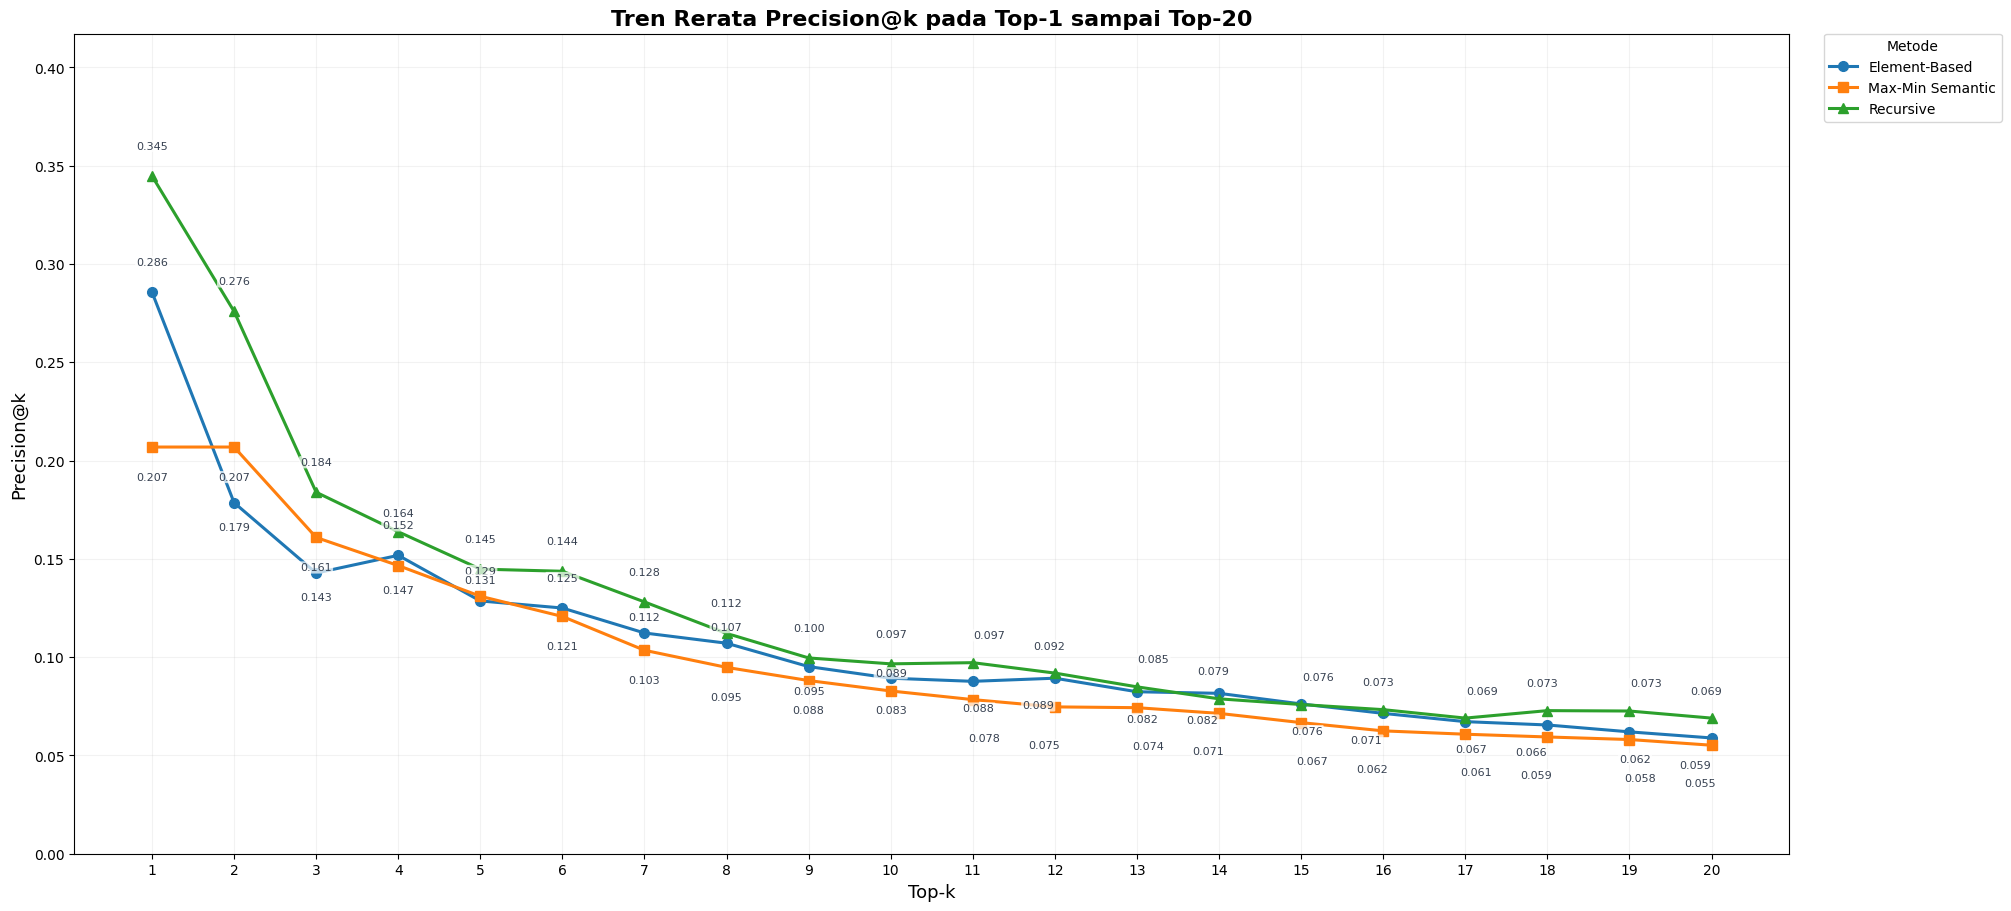

Saved: ..\results\final\analysis\figures\precision_at_k_top1_20.png


In [12]:
plot_metric(
    metric="precision_at_k",
    ylabel="Precision@k",
    title="Tren Rerata Precision@k pada Top-1 sampai Top-20",
    filename="precision_at_k_top1_20.png",
)

## Chart 2: Recall@k Top-1 sampai Top-20

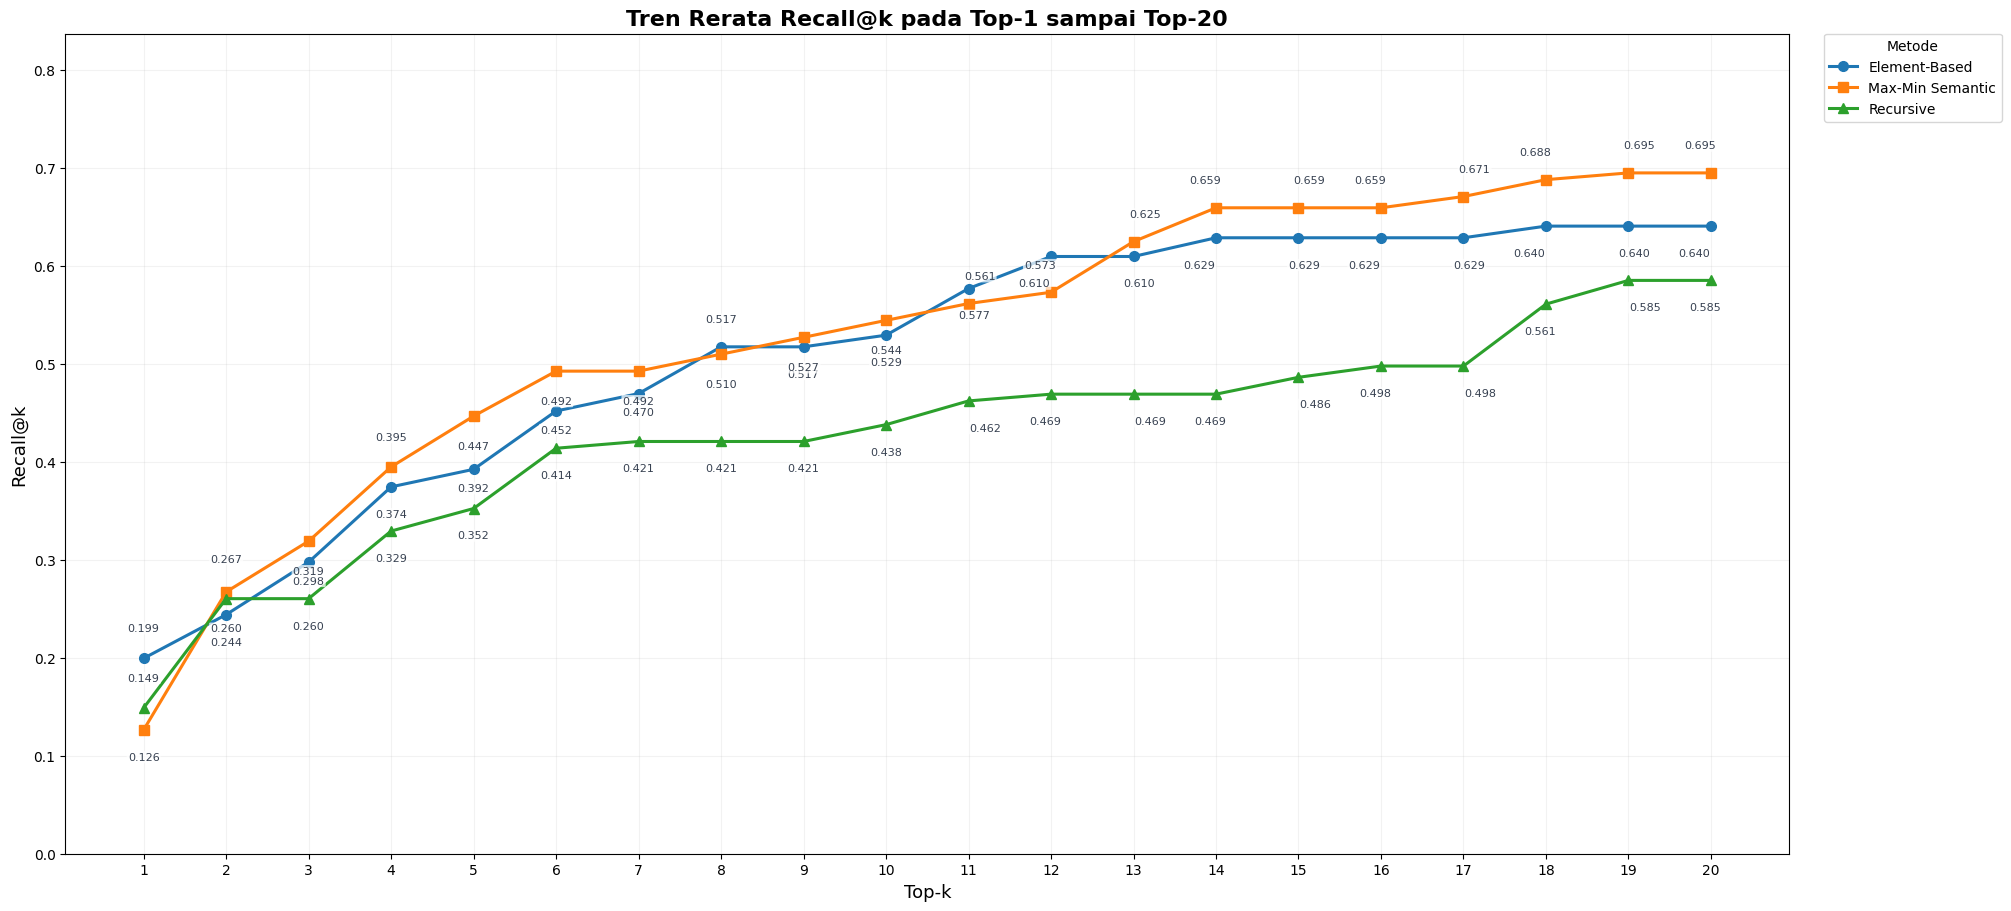

Saved: ..\results\final\analysis\figures\recall_at_k_top1_20.png


In [13]:
plot_metric(
    metric="recall_at_k",
    ylabel="Recall@k",
    title="Tren Rerata Recall@k pada Top-1 sampai Top-20",
    filename="recall_at_k_top1_20.png",
)

## Chart 3: MRR Top-1 sampai Top-20

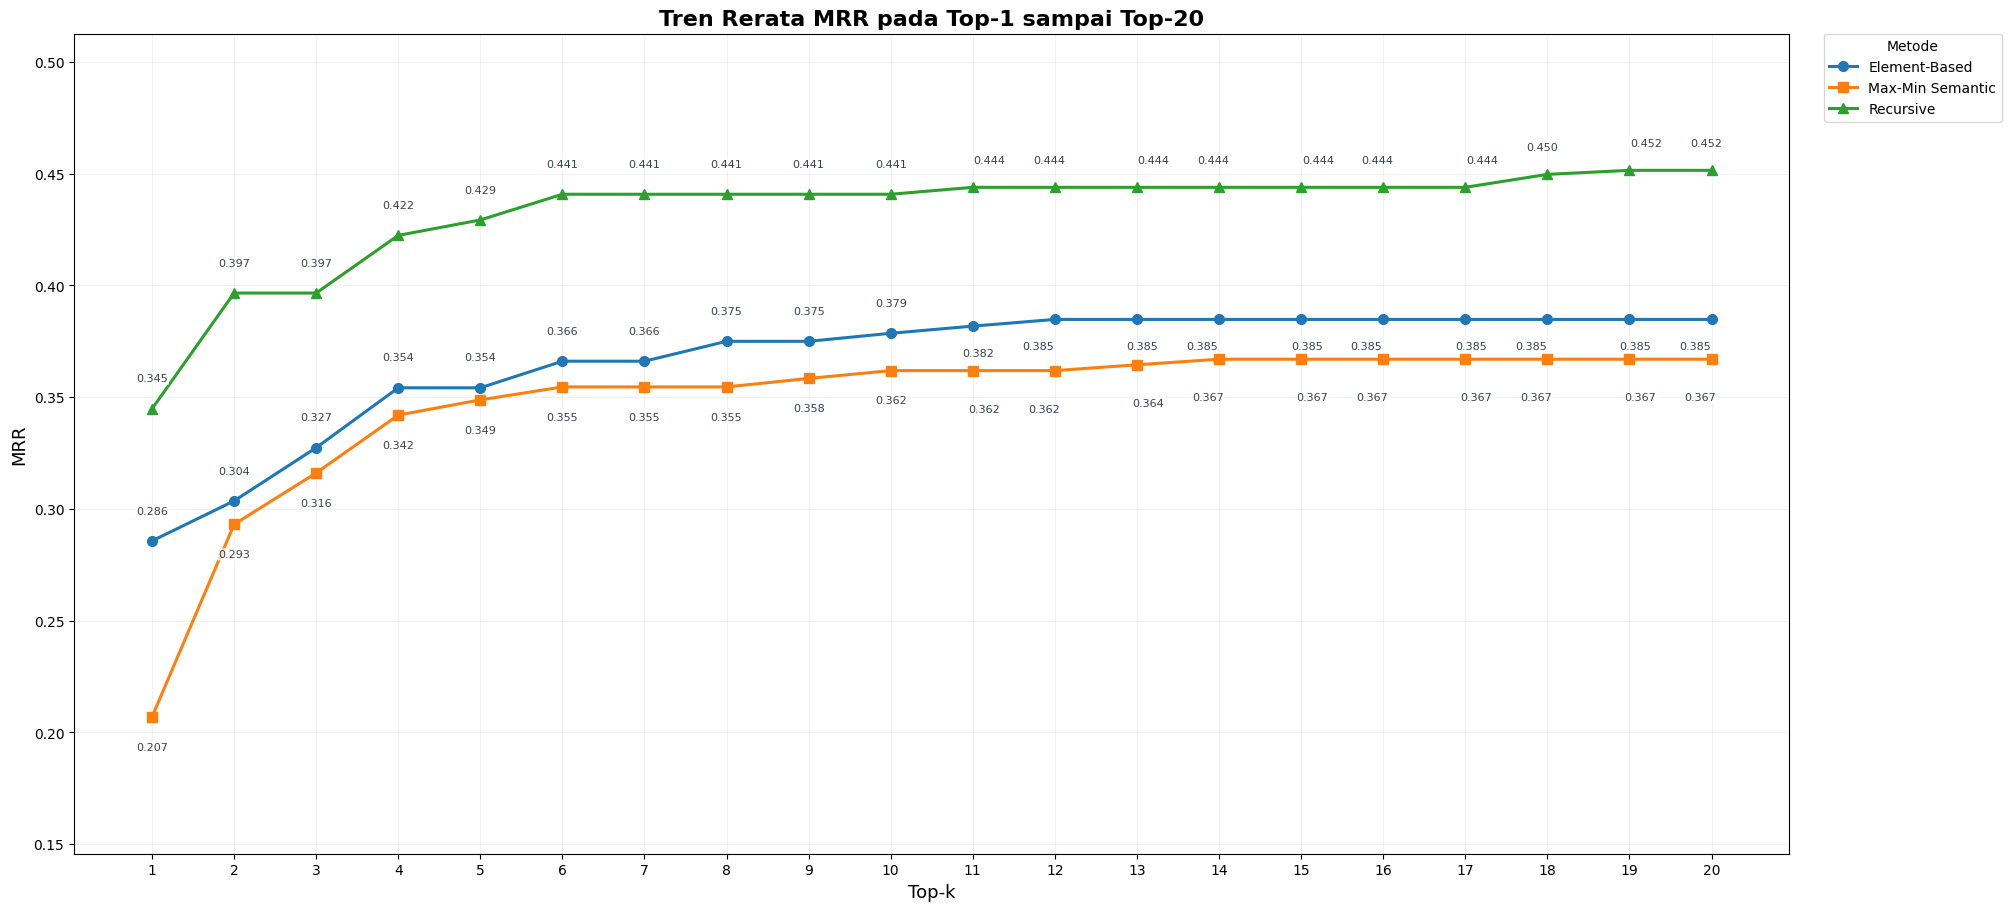

Saved: ..\results\final\analysis\figures\mrr_top1_20.png


In [14]:
plot_metric(
    metric="mrr",
    ylabel="MRR",
    title="Tren Rerata MRR pada Top-1 sampai Top-20",
    filename="mrr_top1_20.png",
)

## Chart 4: F1@k Top-1 sampai Top-20

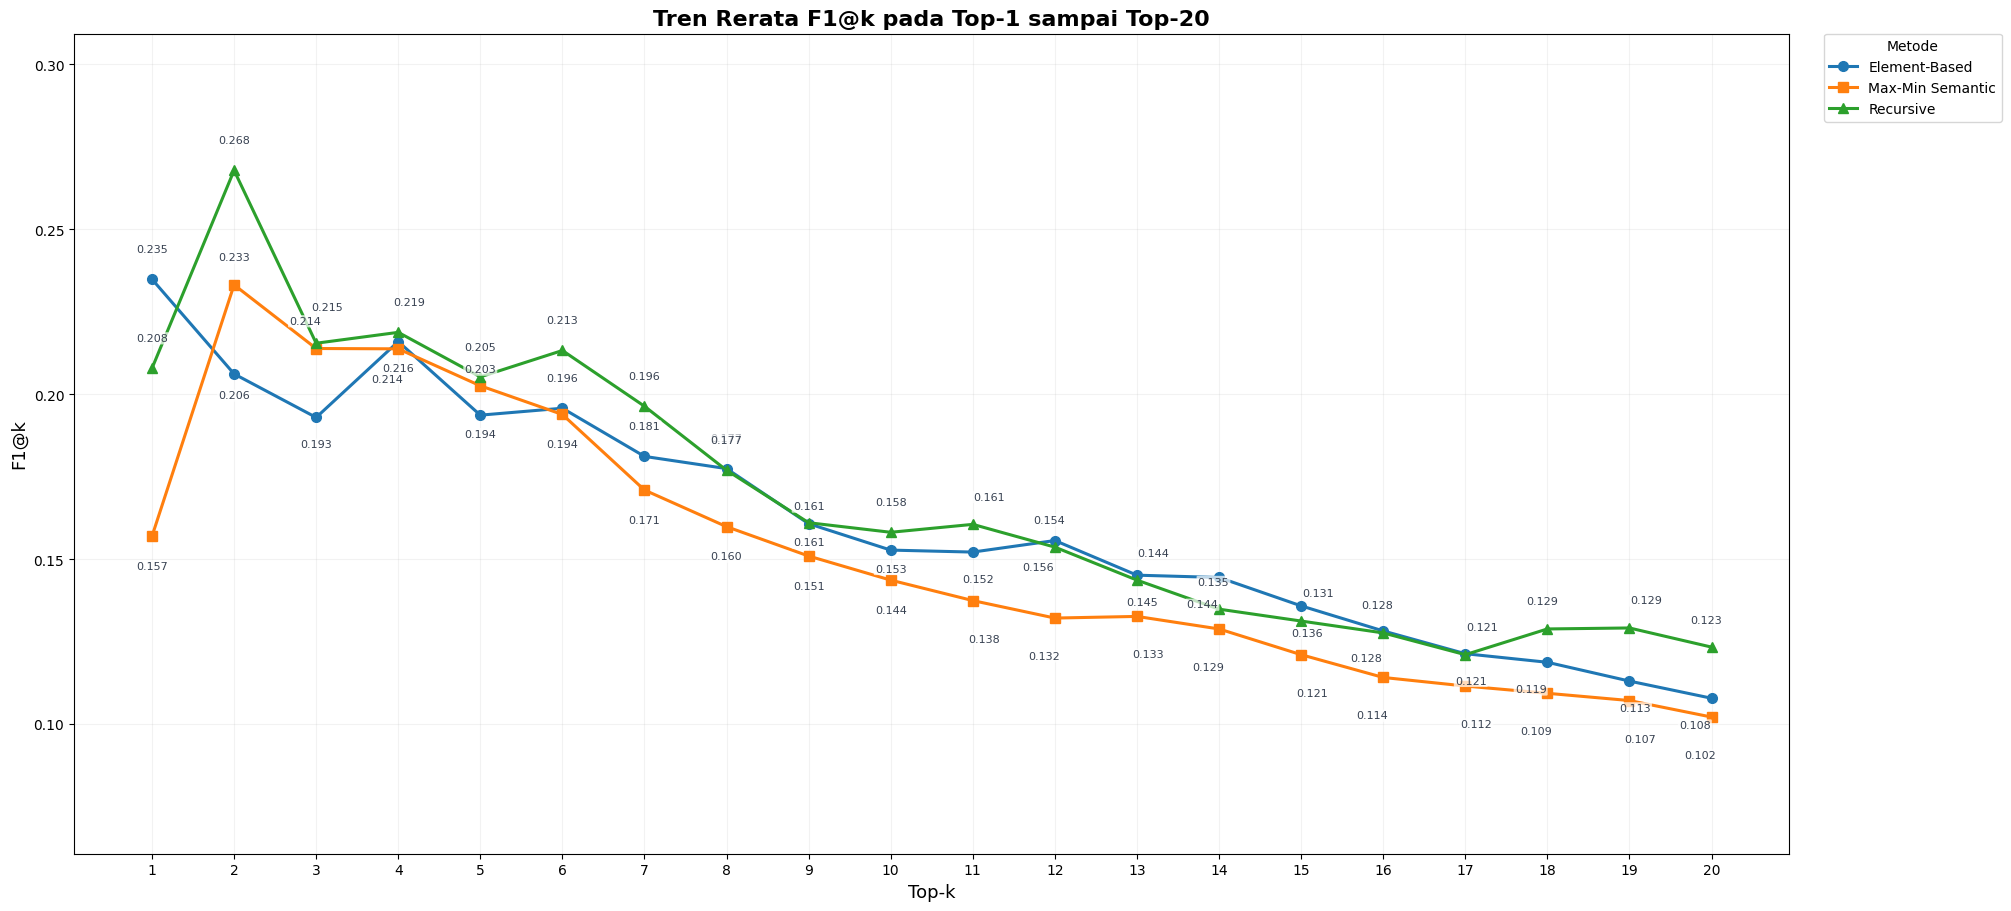

Saved: ..\results\final\analysis\figures\f1_at_k_top1_20.png


In [15]:
plot_metric(
    metric="f1_at_k",
    ylabel="F1@k",
    title="Tren Rerata F1@k pada Top-1 sampai Top-20",
    filename="f1_at_k_top1_20.png",
)

## Chart 5: BLEU Top-1 sampai Top-20

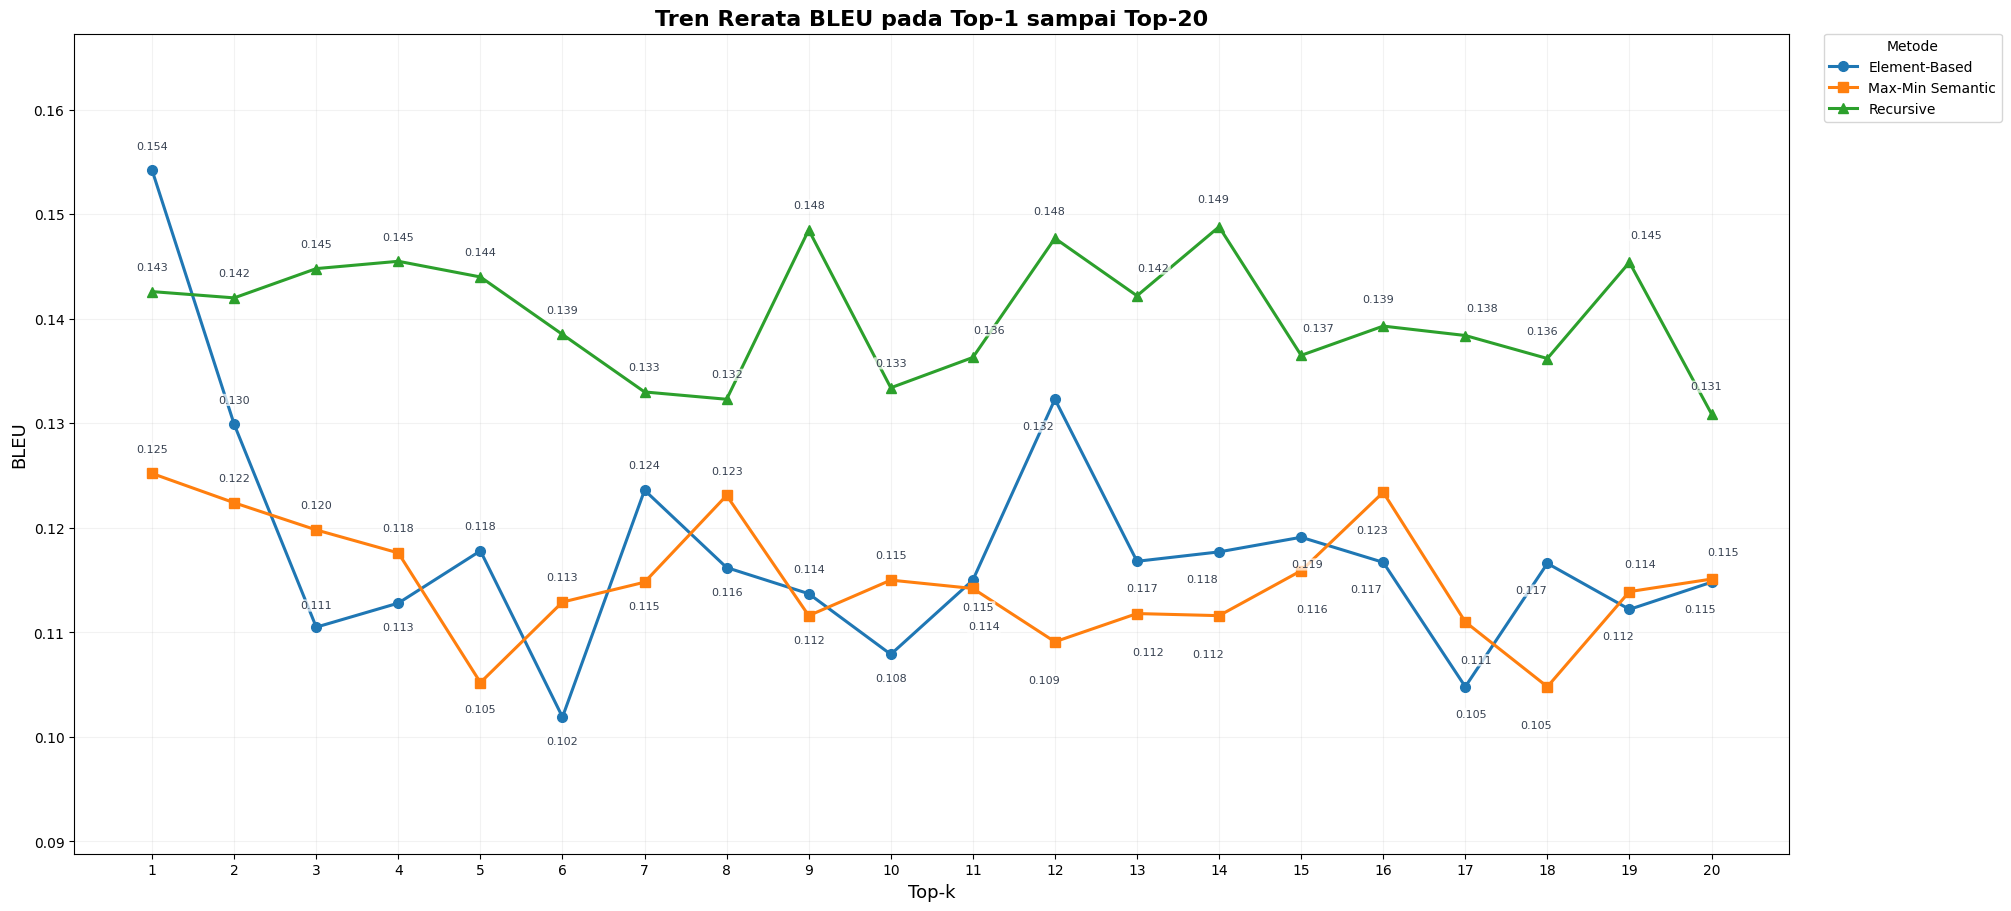

Saved: ..\results\final\analysis\figures\bleu_top1_20.png


In [16]:
plot_metric(
    metric="bleu",
    ylabel="BLEU",
    title="Tren Rerata BLEU pada Top-1 sampai Top-20",
    filename="bleu_top1_20.png",
)

## Chart 6: ROUGE-L Top-1 sampai Top-20

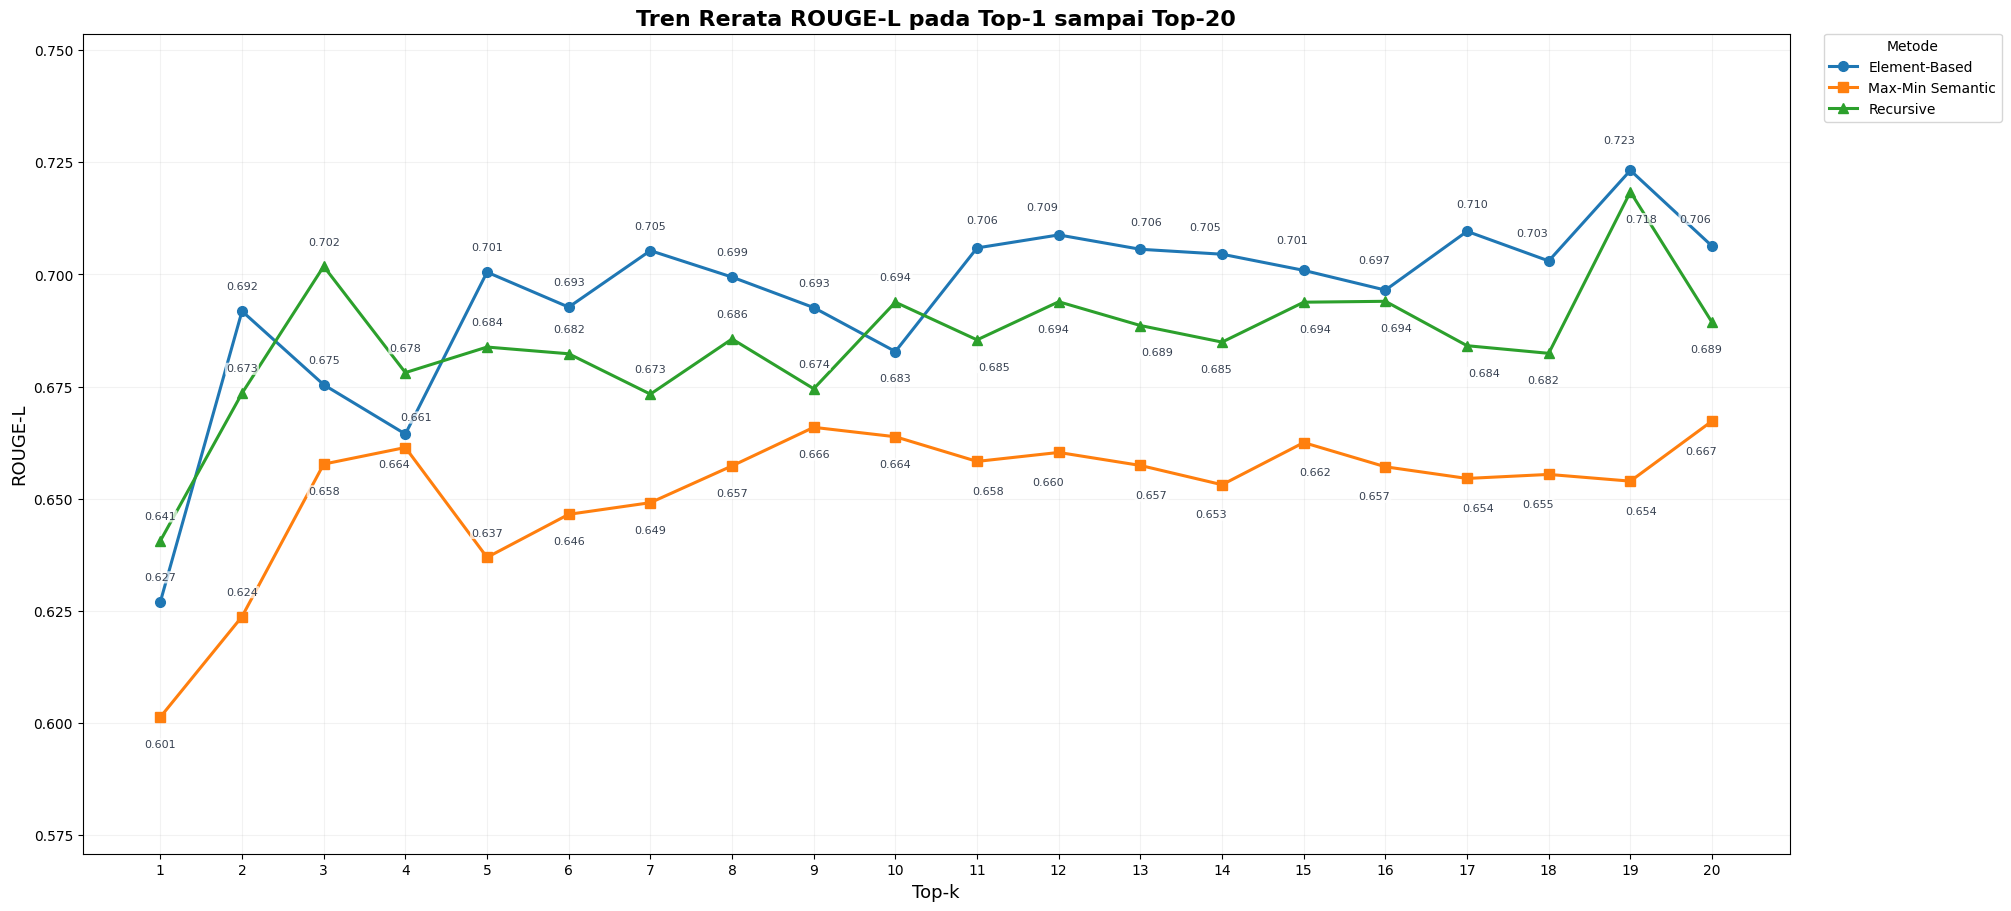

Saved: ..\results\final\analysis\figures\rouge_l_top1_20.png


In [17]:
plot_metric(
    metric="rouge_l",
    ylabel="ROUGE-L",
    title="Tren Rerata ROUGE-L pada Top-1 sampai Top-20",
    filename="rouge_l_top1_20.png",
)

## Tabel Ringkasan dan Pemenang Metrik

In [18]:
display(summary_by_method)
display(metric_winners)

,method,method_key,top_k_count,mean_precision_at_k,mean_recall_at_k,mean_mrr,mean_f1_at_k,mean_bleu,mean_rouge_l
0,Element-Based,element_based,20,0.1079,0.5112,0.3665,0.1617,0.1177,0.6948
1,MaxMin Semantic,maxmin_semantic,20,0.1002,0.5303,0.3474,0.1519,0.1149,0.6522
2,Recursive,recursive,20,0.1239,0.4273,0.4327,0.1688,0.1403,0.6851


,metric,winner_by_top1_20_mean,winner_mean_value,top_k_win_count_element_based,top_k_win_count_maxmin_semantic,top_k_win_count_recursive,tie_top_k_count,basis
0,precision_at_k,Recursive,0.1239,2,0,18,0,highest mean across aggregated Top-1..Top-20 v...
1,recall_at_k,MaxMin Semantic,0.5303,4,16,0,0,highest mean across aggregated Top-1..Top-20 v...
2,mrr,Recursive,0.4327,0,0,20,0,highest mean across aggregated Top-1..Top-20 v...
3,f1_at_k,Recursive,0.1688,8,0,12,0,highest mean across aggregated Top-1..Top-20 v...
4,bleu,Recursive,0.1403,1,0,19,0,highest mean across aggregated Top-1..Top-20 v...
5,rouge_l,Element-Based,0.6948,16,0,4,0,highest mean across aggregated Top-1..Top-20 v...
